# Comparing transits

Transit counterpart of `../full_disks_and_wavelength_shifts/2_compare_disks.ipynb`. That notebook
compares binned disc spectra at a single rotation phase and plots the contrast
`(active - inactive) / inactive` between an active run and its quiet-star counterpart.

Here the same contrast is computed at **every transit position**, using `transit_utils.py`
(the transit analogue of `disk_utils.py`), and animated so the contrast can be watched evolving as
the planet crosses the disc. This notebook sits alongside the transit runs it reads, just as
`2_compare_disks.ipynb` sits alongside the full-disc runs.

Active/inactive pairs follow the same naming convention as `2_compare_disks.ipynb`: the inactive
counterpart of a directory is the same name with the band / lat / long / spot-radius specifiers
zeroed (e.g. `..._fac_lat0_long0_r15_v4000_i90` -> `..._fac_lat0_long0_r0_v4000_i90`).

In [1]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from transit_utils import (
    transit_spectrum_vs_time,
    transit_contrast_vs_time,
    load_transit_directory,
    disc_images,
    inactive_counterpart,
    get_simulation_params,
)

# Set larger font sizes and thicker lines for overall readability
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'lines.markersize': 8
})

# Active directories to compare, { 'directory_path': 'custom label' }. These are the transit runs
# written by transit_disk_save, which live in this folder. The inactive counterpart of each is
# derived automatically, so only list the active runs here.
directories_to_compare = {
    './1_200G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000_i90/': 'Faculae at center V=4000m/s',

    # './1_200G_4376.5109_4377.4913_fac_lat0_long45_r19_v4000_i90/': 'Faculae at blue limb V=4000m/s',
    # './1_200G_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000_i90/': 'Faculae at red limb V=4000m/s',
}

# Distinct (color, marker) per series so a curve stays identifiable, matching 2_compare_disks.ipynb
style_cycle = [
    {'color': '#1f77b4', 'linestyle': '-',  'marker': 'o'},   # blue limb
    {'color': '#2ca02c', 'linestyle': '--', 'marker': 's'},   # centre  -> green
    {'color': '#d62728', 'linestyle': '-.', 'marker': '^'},   # red limb -> red
    {'color': '#9467bd', 'linestyle': ':',  'marker': 'D'},
    {'color': '#ff7f0e', 'linestyle': '-',  'marker': 'v'},
    {'color': '#8c564b', 'linestyle': '--', 'marker': 'P'},
]

comparisons = []  # (active, inactive, label, style)
for i, (active, label) in enumerate(directories_to_compare.items()):
    inactive = inactive_counterpart(active)
    if active == inactive:
        print(f"Skipping {active}: it is its own inactive counterpart (quiet-star reference)")
        continue
    if not Path(inactive).is_dir():
        print(f"Skipping {active}: inactive counterpart {inactive} does not exist")
        continue
    comparisons.append((active, inactive, label, style_cycle[i % len(style_cycle)]))
    print(f"{label}")
    print(f"  active:   {active}")
    print(f"  inactive: {inactive}")
    print(f"  params:   {get_simulation_params(active)}")

if not comparisons:
    raise ValueError("No active/inactive pairs found -- check directories_to_compare.")

Faculae at center V=4000m/s
  active:   ./1_200G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000_i90/
  inactive: ./1_200G_4376.5109_4377.4913_fac_lat0_long0_r0_v4000_i90/
  params:   disk_fill_phase_0=0.08024691358024691, res2d=30, res3d=4, mode=faconly, fac_r=[15], fac_long=[0], fac_lat=[0], fac_band=False, fac_band_low=[-2.5], fac_band_high=[2.5], ld=power2, v_eq=4000, inc=90, rp=0.1808, b=-0.04, N=49, a=2, T=20, phi=0.5, hd_ld_file=test_phot.txt, fac_ld_file=test_fac_200G.txt


## Contrast at every transit position

`transit_contrast_vs_time` bins both runs' Doppler-corrected spectra at each transit position and
returns `(active - inactive) / inactive`, shape `(n_positions, n_bins)`. The first call reads the
disc stacks and bins all positions (slow, ~a minute per directory); results are cached in
`transit_utils`, so the later cells are fast.

In [2]:
contrast_by_pair = {}   # label -> (bin_centers, contrast (n_positions, n_bins))

for active, inactive, label, style in comparisons:
    bin_centers, contrast = transit_contrast_vs_time(active, inactive)
    contrast_by_pair[label] = (bin_centers, contrast)
    print(f"{label}: contrast shape (Position, Wavelength bin) = {contrast.shape}")

n_positions = next(iter(contrast_by_pair.values()))[1].shape[0]
bin_centers = next(iter(contrast_by_pair.values()))[0]
print(f"\n{n_positions} transit positions, {len(bin_centers)} wavelength bins "
      f"({bin_centers.min():.4f}-{bin_centers.max():.4f} A)")

Faculae at center V=4000m/s: contrast shape (Position, Wavelength bin) = (49, 49)

49 transit positions, 49 wavelength bins (4376.5809-4377.4213 A)


## Static overview: contrast map across the transit

One panel per active/inactive pair: contrast as a function of wavelength (x) and transit position
(y), i.e. every frame of the gif below stacked into an image.

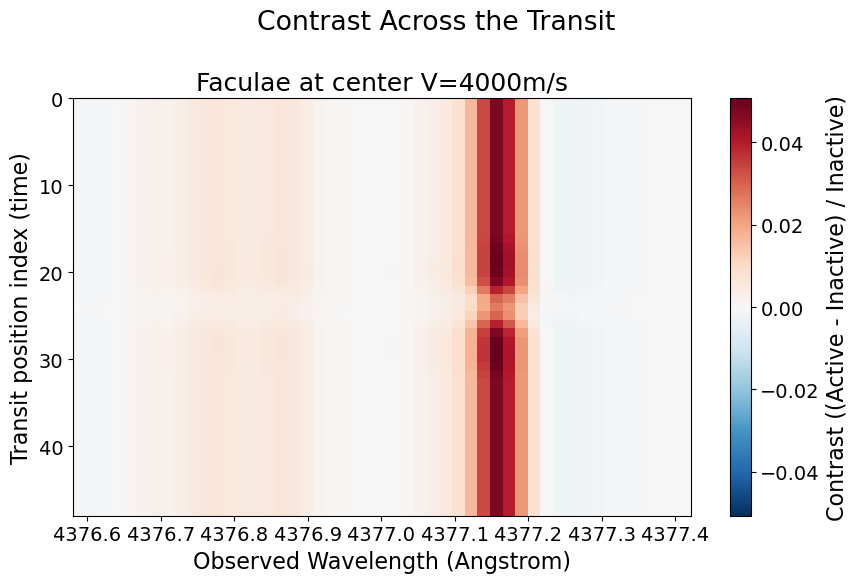

In [3]:
fig, axes = plt.subplots(1, len(contrast_by_pair), figsize=(9 * len(contrast_by_pair), 6),
                         dpi=100, squeeze=False)

for ax, (label, (bc, contrast)) in zip(axes[0], contrast_by_pair.items()):
    vmax = np.nanmax(np.abs(contrast))
    extent = [bc.min(), bc.max(), contrast.shape[0] - 1, 0]
    im = ax.imshow(contrast, aspect='auto', extent=extent, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xlabel('Observed Wavelength (Angstrom)')
    ax.set_ylabel('Transit position index (time)')
    ax.set_title(label)
    fig.colorbar(im, ax=ax, label='Contrast ((Active - Inactive) / Inactive)')

fig.suptitle('Contrast Across the Transit')
fig.tight_layout()
fig.savefig('contrast_across_transit_map.png', dpi=300, bbox_inches='tight')
plt.show()

## Static slice: contrast at a few transit positions

The same data read the other way -- a handful of individual frames overplotted, one line style per
transit position, so the shape of the contrast curve can be compared directly between positions.

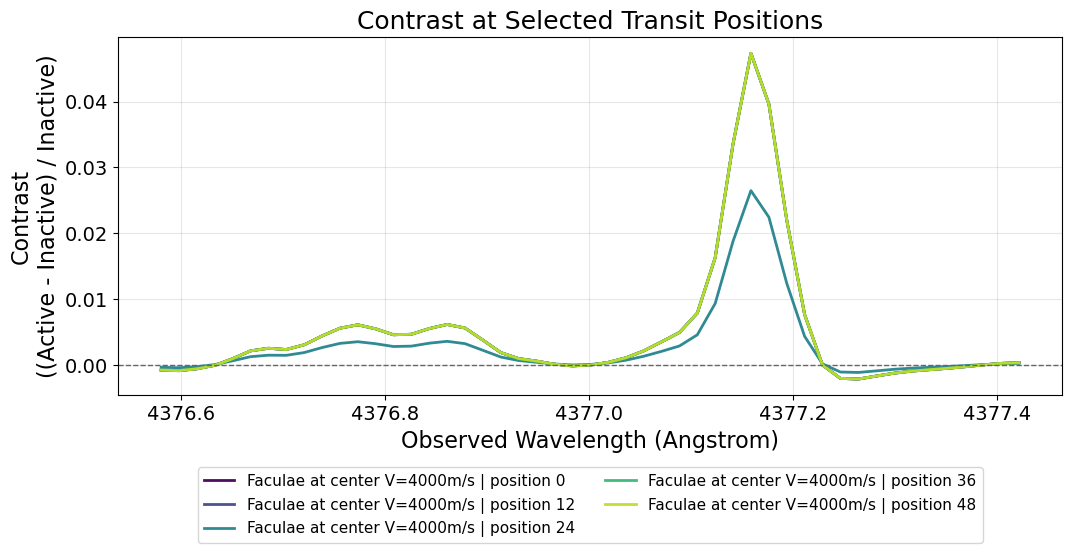

In [4]:
positions_to_show = [0, n_positions // 4, n_positions // 2, 3 * n_positions // 4, n_positions - 1]

fig, ax = plt.subplots(figsize=(11, 6), dpi=100)

for label, (bc, contrast) in contrast_by_pair.items():
    shades = plt.cm.viridis(np.linspace(0, 0.9, len(positions_to_show)))
    for p, shade in zip(positions_to_show, shades):
        ax.plot(bc, contrast[p], color=shade, linewidth=2.0, alpha=0.95,
                label=f'{label} | position {p}')

ax.axhline(0, color='0.4', linestyle='--', linewidth=1)
ax.set_xlabel('Observed Wavelength (Angstrom)')
ax.set_ylabel('Contrast\n((Active - Inactive) / Inactive)')
ax.set_title('Contrast at Selected Transit Positions')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=11)

fig.tight_layout()
fig.savefig('contrast_selected_positions.png', dpi=300, bbox_inches='tight')
plt.show()

## Animated contrast across the transit

Same layout as the spectrum animation in `1_analyze_transits.ipynb`: the left panel is the active
run's stellar disc in pixel intensities with the planet's shadow crossing it, the right panel is the
contrast at that same time-step. Axes are fixed across frames so only the physics moves.

The cell displays an interactive player (play/pause, step forward/back, a slider to scrub to any
transit position, loop mode and a speed control) and also writes a plain `.gif` plus a standalone
`.html` copy of the player.

In [5]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display

gif_path = 'contrast_across_transit.gif'
html_path = 'contrast_across_transit.html'
fps = 5

# to_jshtml() below embeds every frame as a base64 PNG; lift the default 20 MB cap
plt.rcParams['animation.embed_limit'] = 100  # MB

# Left panel follows the first pair's active run (broadband-ish: intensity averaged over wavelength)
disc_label = comparisons[0][2]
disc_vs_time = disc_images(comparisons[0][0])
disc_vmax = disc_vs_time.max()   # fixed colour scale so brightness changes are real, not autoscaling

# Fixed contrast limits across all frames and all pairs
all_contrast = np.concatenate([c.ravel() for _, c in contrast_by_pair.values()])
cmin, cmax = np.nanmin(all_contrast), np.nanmax(all_contrast)
pad = 0.05 * (cmax - cmin)

fig, (ax_disc, ax) = plt.subplots(1, 2, figsize=(17, 6), dpi=100,
                                  gridspec_kw={'width_ratios': [1, 2]})

im_disc = ax_disc.imshow(disc_vs_time[0], cmap='inferno', vmin=0, vmax=disc_vmax)
ax_disc.set_title(f'Disc intensity\n{disc_label}', fontsize=14)
ax_disc.set_xlabel('X')
ax_disc.set_ylabel('Y')
fig.colorbar(im_disc, ax=ax_disc, label='Intensity', fraction=0.046, pad=0.04)

lines = {}
for (label, (bc, contrast)), (_, _, _, style) in zip(contrast_by_pair.items(), comparisons):
    (lines[label],) = ax.plot([], [], linewidth=2.5, alpha=1.0, label=label,
                              **{**style, 'linestyle': '-', 'markersize': 5})
ax.axhline(0, color='0.4', linestyle='--', linewidth=1)
ax.set_xlim(bin_centers.min(), bin_centers.max())
ax.set_ylim(cmin - pad, cmax + pad)
ax.set_xlabel('Observed Wavelength (Angstrom)')
ax.set_ylabel('Contrast\n((Active - Inactive) / Inactive)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=12)
# Placeholder title set before tight_layout so the layout reserves room for it
title = ax.set_title(f'Contrast at Transit Position 0 / {n_positions - 1}')

fig.tight_layout()

def update(i):
    for label, (bc, contrast) in contrast_by_pair.items():
        lines[label].set_data(bc, contrast[i])
    im_disc.set_data(disc_vs_time[i])
    title.set_text(f'Contrast at Transit Position {i} / {n_positions - 1}')
    return (*lines.values(), im_disc, title)

anim = FuncAnimation(fig, update, frames=n_positions, blit=False)

# Interactive player: play / pause / step, a slider to scrub to any transit position, loop mode and a
# speed control. Pure JS embedded in the output, so it needs no ipywidgets, survives being saved into
# the .ipynb, and the .html file opens standalone in a browser.
player_html = anim.to_jshtml(fps=fps)
with open(html_path, 'w') as f:
    f.write(player_html)

anim.save(gif_path, writer=PillowWriter(fps=fps))   # plain gif kept for slides/papers
plt.close(fig)

print(f'Wrote {gif_path} and {html_path} ({n_positions} frames)')
display(HTML(player_html))

Wrote contrast_across_transit.gif and contrast_across_transit.html (49 frames)
